In [9]:
from pathlib import Path

import pandas as pd

csv_path = Path("../data") / "FY_2026_Hospital_Readmissions_Reduction_Program_Hospital.csv"
df = pd.read_csv(csv_path)

df.columns = ( df.columns.
    str.lower(). 
    str.replace(" ", "_")
)

#df.shape
#df.head()
#df.info()
#df.columns
df.isna().sum()
#df.duplicated().sum()

#df.columns

facility_name                     0
facility_id                       0
state                             0
measure_name                      0
number_of_discharges          10088
footnote                      11343
excess_readmission_ratio       6610
predicted_readmission_rate     6610
expected_readmission_rate      6610
number_of_readmissions         6610
start_date                        0
end_date                          0
dtype: int64

In [4]:
df[df['excess_readmission_ratio'].isna()]['measure_name'].value_counts()

#df[df['excess_readmission_ratio'].isna()]['number_of_discharges'].value_counts()

#df[df['excess_readmission_ratio'].isna()]['footnote'].value_counts()


measure_name
READM-30-CABG-HRRP        2177
READM-30-HIP-KNEE-HRRP    1608
READM-30-AMI-HRRP         1319
READM-30-COPD-HRRP         732
READM-30-HF-HRRP           434
READM-30-PN-HRRP           340
Name: count, dtype: int64

In [13]:
df_test = df.copy()
df_test = df_test.dropna(subset = ['excess_readmission_ratio'])

df_test.shape

df_test['measure_name'].value_counts()

df['measure_name'].value_counts()

df_test['footnote'].value_counts()

df_test['number_of_discharges'].mean()

df['number_of_discharges'].mean()

(df_test['excess_readmission_ratio'] > 1).sum()

(df['excess_readmission_ratio'] > 1).sum()

(df_test['excess_readmission_ratio'] <= 1).sum()

(df['excess_readmission_ratio'] <= 1).sum()



np.int64(6077)

In [ ]:
df_test.shape
#(11720, 12)

# Returns the total number of unique combinations
df_test[['facility_id', 'measure_name']].drop_duplicates().shape[0]
#11720 

df_test.groupby('facility_id')['measure_name'].count()

df_test['number_of_readmissions'].value_counts()


df_test.groupby('measure_name')['number_of_readmissions'].value_counts()

In [33]:
df_test['excess_readmission_ratio'].describe()

count    11720.000000
mean         1.001777
std          0.082050
min          0.469800
25%          0.958200
50%          0.997300
75%          1.042300
max          1.629700
Name: excess_readmission_ratio, dtype: float64

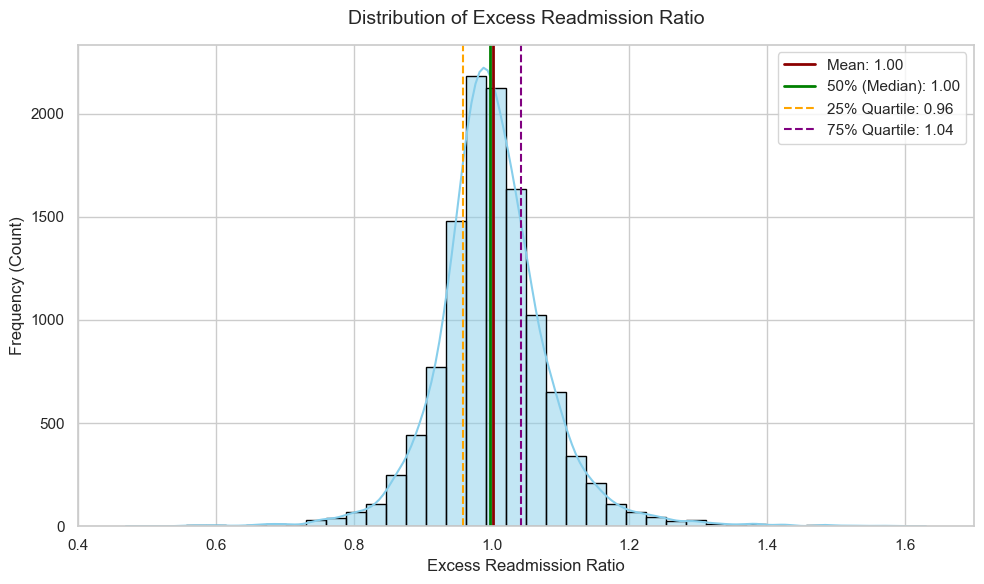

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# 1. Plot the histogram
sns.histplot(df_test['excess_readmission_ratio'], bins=40, kde=True, color='skyblue', edgecolor='black')

# 2. Add statistical line markers from your .describe() output
plt.axvline(1.001777, color='darkred', linestyle='-', linewidth=2, label='Mean: 1.00')
plt.axvline(0.997300, color='green', linestyle='-', linewidth=2, label='50% (Median): 1.00')
plt.axvline(0.958200, color='orange', linestyle='--', linewidth=1.5, label='25% Quartile: 0.96')
plt.axvline(1.042300, color='purple', linestyle='--', linewidth=1.5, label='75% Quartile: 1.04')

# 3. Final formatting adjustments
plt.title('Distribution of Excess Readmission Ratio', fontsize=14, pad=15)
plt.xlabel('Excess Readmission Ratio', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)
plt.xlim(0.4, 1.7) # Matches your absolute min/max range
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()
